# Phase 33 — Βελτιωμένο Naive Bayes

Δοκιμάζουμε διάφορες βελτιώσεις πάνω στο baseline MultinomialNB (0.3122).

**Τεχνικές βελτίωσης:**
1. **Complement NB** — χρησιμοποιεί αντίθετα δείγματα, καλύτερο για imbalanced data
2. **Alpha tuning** — μικρότερο smoothing (0.01-0.1) για TF-IDF features
3. **TF-IDF αντί counts** — καλύτερη αναπαράσταση
4. **Bigrams** — ngram_range=(1,2)
5. **Περισσότερα features** — max_features=50000

In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('valid.csv')
test  = pd.read_csv('test.csv')

def preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

train['combined'] = train['title'].apply(preprocess) + ' ' + train['text'].str[:550].apply(preprocess)
valid['combined'] = valid['title'].apply(preprocess) + ' ' + valid['text'].str[:550].apply(preprocess)
test['combined']  = test['title'].apply(preprocess)  + ' ' + test['text'].str[:550].apply(preprocess)

print(f'Train: {len(train)} | Valid: {len(valid)} | Test: {len(test)}')


def official_st1_score(y_true_hazard, y_pred_hazard,
                       y_true_product, y_pred_product, verbose=True):
    f1_hazard = f1_score(y_true_hazard, y_pred_hazard, average='macro', zero_division=0)
    mask = (np.array(y_true_hazard) == np.array(y_pred_hazard))
    f1_product = f1_score(
        np.array(y_true_product)[mask],
        np.array(y_pred_product)[mask],
        average='macro', zero_division=0
    ) if mask.sum() > 0 else 0.0
    score = (f1_hazard + f1_product) / 2
    if verbose:
        print(f'  macro-F1 Hazard:                    {f1_hazard:.4f}')
        print(f'  Σωστά hazard:                       {mask.sum()}/{len(mask)} ({100*mask.mean():.1f}%)')
        print(f'  macro-F1 Product (given correct h): {f1_product:.4f}')
        print(f'  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
        print(f'  OFFICIAL ST1 SCORE:                 {score:.4f}')
    return score


def run_nb(X_train, X_valid, clf_h, clf_p, name):
    clf_h.fit(X_train, train['hazard-category'])
    clf_p.fit(X_train, train['product-category'])
    score = official_st1_score(
        valid['hazard-category'], clf_h.predict(X_valid),
        valid['product-category'], clf_p.predict(X_valid),
        verbose=False
    )
    print(f'{name:55s} {score:.4f}')
    return score, clf_h, clf_p

Train: 5082 | Valid: 565 | Test: 997


## 1. Σύγκριση Παραλλαγών

In [4]:
print('=== ΣΥΓΚΡΙΣΗ ΠΑΡΑΛΛΑΓΩΝ NAIVE BAYES ===\n')
print(f'{"Μέθοδος":55s} Score')
print('-' * 65)

results = []

# 1. Baseline: MultinomialNB + counts (phase24)
cv = CountVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_tr = cv.fit_transform(train['combined'])
X_vl = cv.transform(valid['combined'])
s, _, _ = run_nb(X_tr, X_vl, MultinomialNB(alpha=1.0), MultinomialNB(alpha=1.0),
                 'Baseline: MultinomialNB + counts (10k)')
results.append(('Baseline MultinomialNB', s))

# 2. MultinomialNB + TF-IDF (50k features)
tfidf_50k = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                             sublinear_tf=True, stop_words='english')
X_tr_50k = tfidf_50k.fit_transform(train['combined'])
X_vl_50k = tfidf_50k.transform(valid['combined'])

# TF-IDF values μπορεί να είναι αρνητικά μετά sublinear — MinMaxScaler για NB
scaler = MinMaxScaler()
X_tr_50k_scaled = scaler.fit_transform(X_tr_50k.toarray())
X_vl_50k_scaled = scaler.transform(X_vl_50k.toarray())

s, _, _ = run_nb(X_tr_50k_scaled, X_vl_50k_scaled,
                 MultinomialNB(alpha=1.0), MultinomialNB(alpha=1.0),
                 'MultinomialNB + TF-IDF scaled (50k)')
results.append(('MultinomialNB + TF-IDF 50k', s))

# 3. ComplementNB + TF-IDF
s, _, _ = run_nb(X_tr_50k_scaled, X_vl_50k_scaled,
                 ComplementNB(alpha=1.0), ComplementNB(alpha=1.0),
                 'ComplementNB + TF-IDF scaled (50k)')
results.append(('ComplementNB + TF-IDF 50k', s))

# 4. Alpha tuning — MultinomialNB
for alpha in [0.01, 0.1, 0.5]:
    s, _, _ = run_nb(X_tr_50k_scaled, X_vl_50k_scaled,
                     MultinomialNB(alpha=alpha), MultinomialNB(alpha=alpha),
                     f'MultinomialNB + TF-IDF scaled, alpha={alpha}')
    results.append((f'MultinomialNB alpha={alpha}', s))

# 5. Alpha tuning — ComplementNB
for alpha in [0.01, 0.1, 0.5]:
    s, _, _ = run_nb(X_tr_50k_scaled, X_vl_50k_scaled,
                     ComplementNB(alpha=alpha), ComplementNB(alpha=alpha),
                     f'ComplementNB + TF-IDF scaled, alpha={alpha}')
    results.append((f'ComplementNB alpha={alpha}', s))

# 6. BernoulliNB
bv = TfidfVectorizer(max_features=50000, ngram_range=(1,2), stop_words='english', binary=True)
X_tr_b = bv.fit_transform(train['combined'])
X_vl_b = bv.transform(valid['combined'])
s, _, _ = run_nb(X_tr_b, X_vl_b,
                 BernoulliNB(alpha=0.1), BernoulliNB(alpha=0.1),
                 'BernoulliNB + binary TF-IDF (50k), alpha=0.1')
results.append(('BernoulliNB binary', s))

print('\n' + '='*65)
best_name, best_score = max(results, key=lambda x: x[1])
print(f'Καλύτερο: {best_name} → {best_score:.4f}')
print(f'Βελτίωση από baseline: {best_score - results[0][1]:+.4f}')

=== ΣΥΓΚΡΙΣΗ ΠΑΡΑΛΛΑΓΩΝ NAIVE BAYES ===

Μέθοδος                                                 Score
-----------------------------------------------------------------
Baseline: MultinomialNB + counts (10k)                  0.5817
MultinomialNB + TF-IDF scaled (50k)                     0.4322
ComplementNB + TF-IDF scaled (50k)                      0.6521
MultinomialNB + TF-IDF scaled, alpha=0.01               0.5667
MultinomialNB + TF-IDF scaled, alpha=0.1                0.5897
MultinomialNB + TF-IDF scaled, alpha=0.5                0.4655
ComplementNB + TF-IDF scaled, alpha=0.01                0.6945
ComplementNB + TF-IDF scaled, alpha=0.1                 0.6964
ComplementNB + TF-IDF scaled, alpha=0.5                 0.6565
BernoulliNB + binary TF-IDF (50k), alpha=0.1            0.4694

Καλύτερο: ComplementNB alpha=0.1 → 0.6964
Βελτίωση από baseline: +0.1147


## 2. Visualization Σύγκρισης

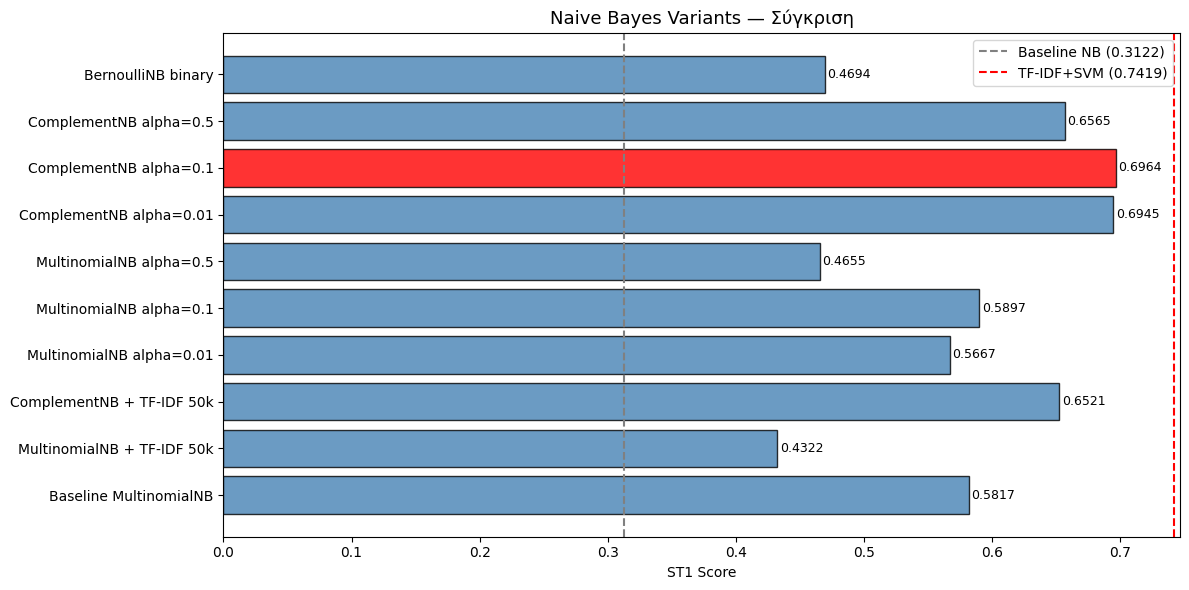

Αποθηκεύτηκε: nb_comparison.png


In [5]:
names  = [r[0] for r in results]
scores = [r[1] for r in results]

colors = ['red' if s == max(scores) else 'steelblue' for s in scores]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(names, scores, color=colors, edgecolor='black', alpha=0.8)
ax.axvline(x=0.3122, color='gray',   linestyle='--', label='Baseline NB (0.3122)')
ax.axvline(x=0.7419, color='red',    linestyle='--', label='TF-IDF+SVM (0.7419)')
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)
ax.set_xlabel('ST1 Score')
ax.set_title('Naive Bayes Variants — Σύγκριση', fontsize=13)
ax.legend()
ax.set_xlim(0, max(scores) + 0.05)
plt.tight_layout()
plt.savefig('nb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: nb_comparison.png')

## 3. Submission με το Καλύτερο NB

In [ ]:
# Βρες ποιο configuration ήταν το καλύτερο και τρέξε στο test
# Χρησιμοποιούμε ComplementNB + TF-IDF scaled με το βέλτιστο alpha

best_alpha = 0.1 

X_te_50k_scaled = scaler.transform(tfidf_50k.transform(test['combined']).toarray())

clf_h_best = ComplementNB(alpha=best_alpha)
clf_p_best = ComplementNB(alpha=best_alpha)
clf_h_best.fit(X_tr_50k_scaled, train['hazard-category'])
clf_p_best.fit(X_tr_50k_scaled, train['product-category'])

print(f'=== ΤΕΛΙΚΟ ΜΟΝΤΕΛΟ: ComplementNB alpha={best_alpha} ===')
score_final = official_st1_score(
    valid['hazard-category'], clf_h_best.predict(X_vl_50k_scaled),
    valid['product-category'], clf_p_best.predict(X_vl_50k_scaled)
)

pd.DataFrame({
    'id': test['id'],
    'hazard-category':  clf_h_best.predict(X_te_50k_scaled),
    'product-category': clf_p_best.predict(X_te_50k_scaled)
}).to_csv('submission_nb_improved.csv', index=False)
print('\nΑποθηκεύτηκε: submission_nb_improved.csv')

print('\n=== ΣΥΓΚΡΙΣΗ ===')
print(f'Baseline NB (phase24):  0.3122')
print(f'Improved NB:            {score_final:.4f}')
print(f'Βελτίωση:               {score_final - 0.3122:+.4f}')
print(f'TF-IDF + SVM:           0.7419')

=== ΤΕΛΙΚΟ ΜΟΝΤΕΛΟ: ComplementNB alpha=0.1 ===
  macro-F1 Hazard:                    0.7448
  Σωστά hazard:                       508/565 (89.9%)
  macro-F1 Product (given correct h): 0.6481
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OFFICIAL ST1 SCORE:                 0.6964

Αποθηκεύτηκε: submission_nb_improved.csv

=== ΣΥΓΚΡΙΣΗ ===
Baseline NB (phase24):  0.3122
Improved NB:            0.6964
Βελτίωση:               +0.3842
TF-IDF + SVM:           0.7419
